# IADATA708 — Fairness, Interpretability & Robustness
## Pokec — Node Classification (Job Prediction)

**Pipeline :** EDA → Preprocessing → Graph → Baseline GraphSAGE → Adversarial Debiasing → GNNExplainer → Robustness

In [18]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')

PyTorch 2.10.0+cpu | Device: cpu


## 1. Chargement des données

In [19]:
DATA_DIR = '../data/raw/undersampled/'

df = pd.read_csv(DATA_DIR + 'region_job.csv')

edges_df = pd.read_csv(
    DATA_DIR + 'region_job_relationship.txt',
    sep='\t', header=None, names=['src', 'dst']
)

print(f'Noeuds : {len(df):,}  |  Aretes brutes : {len(edges_df):,}')
df.head(3)

Noeuds : 67,796  |  Aretes brutes : 882,765


,user_id,public,completion_percentage,gender,region,AGE,I_am_working_in_field,spoken_languages_indicator,anglicky,nemecky,...,odbornu literaturu,psychologicku literaturu,literaturu pre rozvoj osobnosti,cestopisy,literaturu faktu,poeziu,zivotopisne a pamate,pocitacovu literaturu,filozoficku literaturu,literaturu o umeni a architekture
0,1,1,14,1.0,0,26.0,-1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,131075,0,33,1.0,1,25.0,-1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,5,1,66,1.0,0,26.0,3,1,1,1,...,0,0,0,0,0,0,0,0,0,0


## 2. EDA

Distribution cible (I_am_working_in_field):
I_am_working_in_field
-1    57534
 0     4764
 1     1964
 3     1287
 2     1266
 4      981
Name: count, dtype: int64

Gender : {0.0: 34308, 1.0: 33488}
AGE — mean: 17.2, median: 19.0


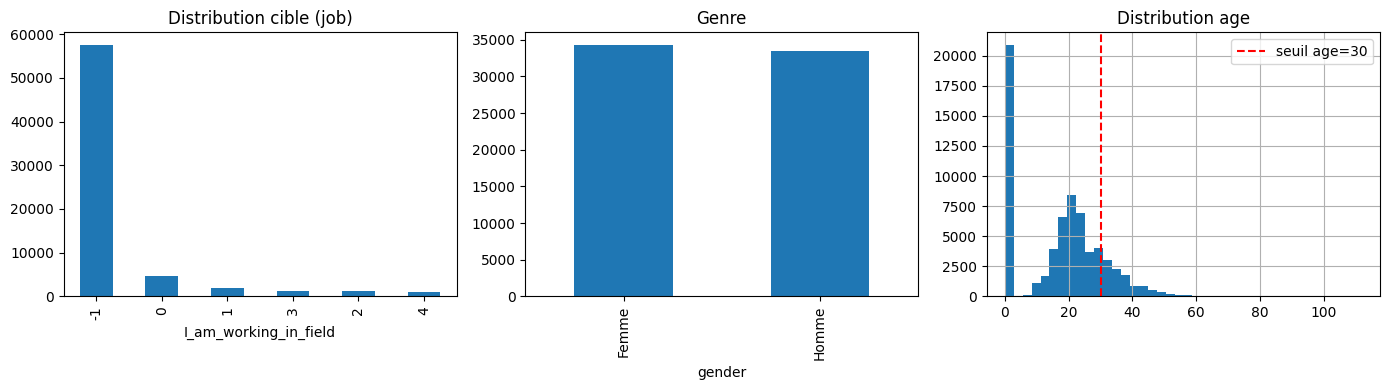

In [20]:
print('Distribution cible (I_am_working_in_field):')
print(df['I_am_working_in_field'].value_counts())
print(f"\nGender : {df['gender'].value_counts().to_dict()}")
print(f"AGE — mean: {df['AGE'].mean():.1f}, median: {df['AGE'].median():.1f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df['I_am_working_in_field'].value_counts().plot(kind='bar', ax=axes[0], title='Distribution cible (job)')
df['gender'].value_counts().rename({1.0: 'Homme', 0.0: 'Femme'}).plot(kind='bar', ax=axes[1], title='Genre')
df['AGE'].hist(bins=40, ax=axes[2])
axes[2].axvline(30, color='red', linestyle='--', label='seuil age=30')
axes[2].set_title('Distribution age')
axes[2].legend()
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [21]:
df = df.dropna(subset=['gender']).copy()
df['gender'] = df['gender'].astype(int)

# Cible binaire : travailler dans un domaine = 1, sinon 0
df['label'] = (df['I_am_working_in_field'] > 0).astype(int)

# Attribut sensible secondaire : age binarise
df['age_group'] = (df['AGE'] >= 30).astype(int)

print(f'Noeuds apres nettoyage : {len(df):,}')
print(f'Label balance : {df["label"].mean():.2%} positif')
print(f'Gender balance : {df["gender"].mean():.2%} hommes')
print(f'Age group : {df["age_group"].mean():.2%} seniors (>=30)')

Noeuds apres nettoyage : 67,796
Label balance : 8.11% positif
Gender balance : 49.40% hommes
Age group : 16.92% seniors (>=30)


In [22]:
EXCLUDE = ['user_id', 'gender', 'AGE', 'I_am_working_in_field', 'label', 'age_group']
feature_cols = [c for c in df.columns if c not in EXCLUDE]

X               = df[feature_cols].fillna(0).values.astype(np.float32)
y               = df['label'].values
sensitive_gender = df['gender'].values
sensitive_age   = df['age_group'].values
user_ids        = df['user_id'].values

print(f'Feature matrix : {X.shape}')

Feature matrix : (67796, 275)


In [23]:
# Split 60/20/20 stratifie
indices = np.arange(len(df))
idx_train, idx_temp = train_test_split(indices, test_size=0.4, random_state=42, stratify=y)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.5, random_state=42, stratify=y[idx_temp])

train_mask = torch.zeros(len(df), dtype=torch.bool)
val_mask   = torch.zeros(len(df), dtype=torch.bool)
test_mask  = torch.zeros(len(df), dtype=torch.bool)
train_mask[idx_train] = True
val_mask[idx_val]     = True
test_mask[idx_test]   = True

print(f'Train: {train_mask.sum()} | Val: {val_mask.sum()} | Test: {test_mask.sum()}')

# Poids de classe pour corriger le desequilibre (8% positif)
counts = torch.bincount(torch.tensor(y[idx_train]))
CLASS_WEIGHTS = (1.0 / counts.float())
CLASS_WEIGHTS = (CLASS_WEIGHTS / CLASS_WEIGHTS.sum() * 2)
print(f'Class weights: {CLASS_WEIGHTS.tolist()}')

Train: 40677 | Val: 13559 | Test: 13560
Class weights: [0.16220468282699585, 1.837795376777649]


## 4. Construction du graphe (PyTorch Geometric)

In [24]:
id_map = {uid: i for i, uid in enumerate(user_ids)}

mask_e = edges_df['src'].isin(id_map) & edges_df['dst'].isin(id_map)
ef     = edges_df[mask_e]
src    = ef['src'].map(id_map).values
dst    = ef['dst'].map(id_map).values

# Graphe non-dirige
edge_index = torch.tensor(
    np.stack([np.concatenate([src, dst]), np.concatenate([dst, src])]),
    dtype=torch.long
)

data = Data(
    x=torch.tensor(X, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.long),
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)
data.sensitive_gender = torch.tensor(sensitive_gender, dtype=torch.long)
data.sensitive_age    = torch.tensor(sensitive_age, dtype=torch.long)
data = data.to(DEVICE)

print(data)
print(f'Aretes apres filtrage : {edge_index.shape[1] // 2:,}')

Data(x=[67796, 275], edge_index=[2, 1765530], y=[67796], train_mask=[67796], val_mask=[67796], test_mask=[67796], sensitive_gender=[67796], sensitive_age=[67796])
Aretes apres filtrage : 882,765


## 5. Metriques de performance et d'equite

In [25]:
def spd(y_pred, sens):
    """Statistical Parity Difference = P(yhat=1|s=1) - P(yhat=1|s=0)"""
    y_pred, sens = np.array(y_pred), np.array(sens)
    return y_pred[sens == 1].mean() - y_pred[sens == 0].mean()

def eod(y_true, y_pred, sens):
    """Equal Opportunity Difference = TPR(s=1) - TPR(s=0)"""
    y_true, y_pred, sens = np.array(y_true), np.array(y_pred), np.array(sens)
    return y_pred[(sens==1)&(y_true==1)].mean() - y_pred[(sens==0)&(y_true==1)].mean()

def evaluate(model, data, mask, sensitive_attr, is_fair=False):
    model.eval()
    with torch.no_grad():
        out = model.predict(data.x, data.edge_index) if is_fair else model(data.x, data.edge_index)
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()
    m, s, yt = mask.cpu().numpy(), sensitive_attr.cpu().numpy(), data.y.cpu().numpy()
    return {
        'Accuracy': accuracy_score(yt[m], preds[m]),
        'AUC-ROC':  roc_auc_score(yt[m], probs[m]),
        'SPD':      spd(preds[m], s[m]),
        'EOD':      eod(yt[m], preds[m], s[m]),
    }

## 6. Baseline : GraphSAGE

In [26]:
class GraphSAGE(nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch, dropout=0.5):
        super().__init__()
        self.conv1   = SAGEConv(in_ch, hid_ch)
        self.conv2   = SAGEConv(hid_ch, out_ch)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)

    # Alias pour interface commune avec FairGraphSAGE
    def predict(self, x, edge_index):
        return self.forward(x, edge_index)

In [ ]:
def train_baseline(model, data, epochs=20, lr=0.01):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    w   = CLASS_WEIGHTS.to(DEVICE)
    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        loss = F.cross_entropy(
            model(data.x, data.edge_index)[data.train_mask],
            data.y[data.train_mask],
            weight=w
        )
        loss.backward()
        opt.step()
        if epoch % 5 == 0:
            m = evaluate(model, data, data.val_mask, data.sensitive_gender)
            print(f'Epoch {epoch:3d} | Loss: {loss.item():.4f} | Val Acc: {m["Accuracy"]:.4f} | Val AUC: {m["AUC-ROC"]:.4f}')

baseline = GraphSAGE(data.x.shape[1], 64, 2).to(DEVICE)
train_baseline(baseline, data)

Epoch   5 | Loss: 1.1613 | Val Acc: 0.3176 | Val AUC: 0.7661
Epoch  10 | Loss: 0.6916 | Val Acc: 0.8392 | Val AUC: 0.7278
Epoch  15 | Loss: 0.5818 | Val Acc: 0.4616 | Val AUC: 0.7617
Epoch  20 | Loss: 0.5614 | Val Acc: 0.4898 | Val AUC: 0.7686


In [ ]:
print('=== BASELINE GraphSAGE — Test set ===\n')
for name, attr in [('Genre', data.sensitive_gender), ('Age', data.sensitive_age)]:
    res = evaluate(baseline, data, data.test_mask, attr)
    print(f'Attribut sensible : {name}')
    for k, v in res.items():
        print(f'  {k:10s}: {v:+.4f}')
    print()   

=== BASELINE GraphSAGE — Test set ===

Attribut sensible : Genre
  Accuracy  : +0.4923
  AUC-ROC   : +0.7759
  SPD       : +0.0164
  EOD       : -0.0112

Attribut sensible : Age
  Accuracy  : +0.4923
  AUC-ROC   : +0.7759
  SPD       : -0.0603
  EOD       : -0.0464



## 7. Methode d'equite : Adversarial Debiasing

In [29]:
class FairGraphSAGE(nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch, dropout=0.5):
        super().__init__()
        self.conv1   = SAGEConv(in_ch, hid_ch)
        self.conv2   = SAGEConv(hid_ch, out_ch)
        self.dropout = dropout

    def forward(self, x, edge_index):
        h   = F.relu(self.conv1(x, edge_index))
        h   = F.dropout(h, p=self.dropout, training=self.training)
        out = self.conv2(h, edge_index)
        return out, h

    def predict(self, x, edge_index):
        out, _ = self.forward(x, edge_index)
        return out


class Adversary(nn.Module):
    def __init__(self, hid_ch):
        super().__init__()
        self.fc = nn.Linear(hid_ch, 2)

    def forward(self, h):
        return self.fc(h)

In [ ]:
def train_fair(fair_model, adversary, data, lam=1.0, epochs=20, lr=0.01):
    """
    lam : poids de la penalite adversariale.
    Augmenter lam = plus d'equite, moins de performance.
    """
    opt_m = torch.optim.Adam(fair_model.parameters(), lr=lr, weight_decay=5e-4)
    opt_a = torch.optim.Adam(adversary.parameters(), lr=lr)
    w     = CLASS_WEIGHTS.to(DEVICE)

    for epoch in range(1, epochs + 1):
        fair_model.train(); adversary.train()

        # Etape 1 : entrainer l'adversaire
        opt_a.zero_grad()
        with torch.no_grad():
            _, h = fair_model(data.x, data.edge_index)
        F.cross_entropy(adversary(h[data.train_mask]), data.sensitive_gender[data.train_mask]).backward()
        opt_a.step()

        # Etape 2 : entrainer le modele principal
        opt_m.zero_grad()
        out, h    = fair_model(data.x, data.edge_index)
        task_loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=w)
        adv_loss  = F.cross_entropy(adversary(h[data.train_mask]), data.sensitive_gender[data.train_mask])
        (task_loss - lam * adv_loss).backward()
        opt_m.step()

        if epoch % 5 == 0:
            fair_model.eval()
            with torch.no_grad():
                preds = fair_model.predict(data.x, data.edge_index).argmax(dim=1).cpu().numpy()
            m   = data.val_mask.cpu().numpy()
            acc = accuracy_score(data.y.cpu().numpy()[m], preds[m])
            s   = spd(preds[m], data.sensitive_gender.cpu().numpy()[m])
            print(f'Epoch {epoch:3d} | Task: {task_loss.item():.4f} | Val Acc: {acc:.4f} | |SPD|: {abs(s):.4f}')


fair_model = FairGraphSAGE(data.x.shape[1], 64, 2).to(DEVICE)
adversary  = Adversary(64).to(DEVICE)
train_fair(fair_model, adversary, data, lam=1.0)


Epoch   5 | Task: 1.0937 | Val Acc: 0.1618 | |SPD|: 0.0089
Epoch  10 | Task: 1.2235 | Val Acc: 0.4832 | |SPD|: 0.0265
Epoch  15 | Task: 0.9844 | Val Acc: 0.5056 | |SPD|: 0.0239
Epoch  20 | Task: 0.8966 | Val Acc: 0.5098 | |SPD|: 0.0234


=== Comparaison Test set (Genre) ===

          Baseline  Fair (lam=1.0)
Accuracy    0.4923          0.5151
AUC-ROC     0.7759          0.7455
SPD         0.0164          0.0151
EOD        -0.0112         -0.0152


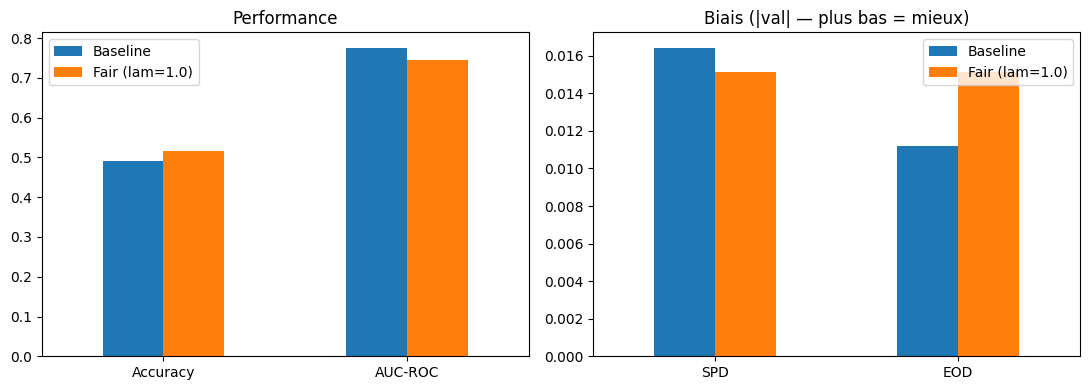

In [31]:
res_base = evaluate(baseline, data, data.test_mask, data.sensitive_gender)
res_fair = evaluate(fair_model, data, data.test_mask, data.sensitive_gender, is_fair=True)

comp = pd.DataFrame({'Baseline': res_base, 'Fair (lam=1.0)': res_fair})
print('=== Comparaison Test set (Genre) ===\n')
print(comp.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
comp.loc[['Accuracy', 'AUC-ROC']].plot(kind='bar', ax=axes[0], title='Performance')
comp.loc[['SPD', 'EOD']].abs().plot(kind='bar', ax=axes[1], title='Biais (|val| — plus bas = mieux)')
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 8. Interpretabilite : GNNExplainer

In [32]:
from torch_geometric.explain import Explainer, GNNExplainer

explainer = Explainer(
    model=baseline,
    algorithm=GNNExplainer(epochs=5),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type=None,
    model_config=dict(mode='multiclass_classification', task_level='node', return_type='raw'),
)

test_idx   = data.test_mask.nonzero(as_tuple=True)[0]
male_idx   = test_idx[data.sensitive_gender[test_idx] == 1][0].item()
female_idx = test_idx[data.sensitive_gender[test_idx] == 0][0].item()

exp_m = explainer(data.x, data.edge_index, index=male_idx)
exp_f = explainer(data.x, data.edge_index, index=female_idx)
print('Explications generees.')

Explications generees.


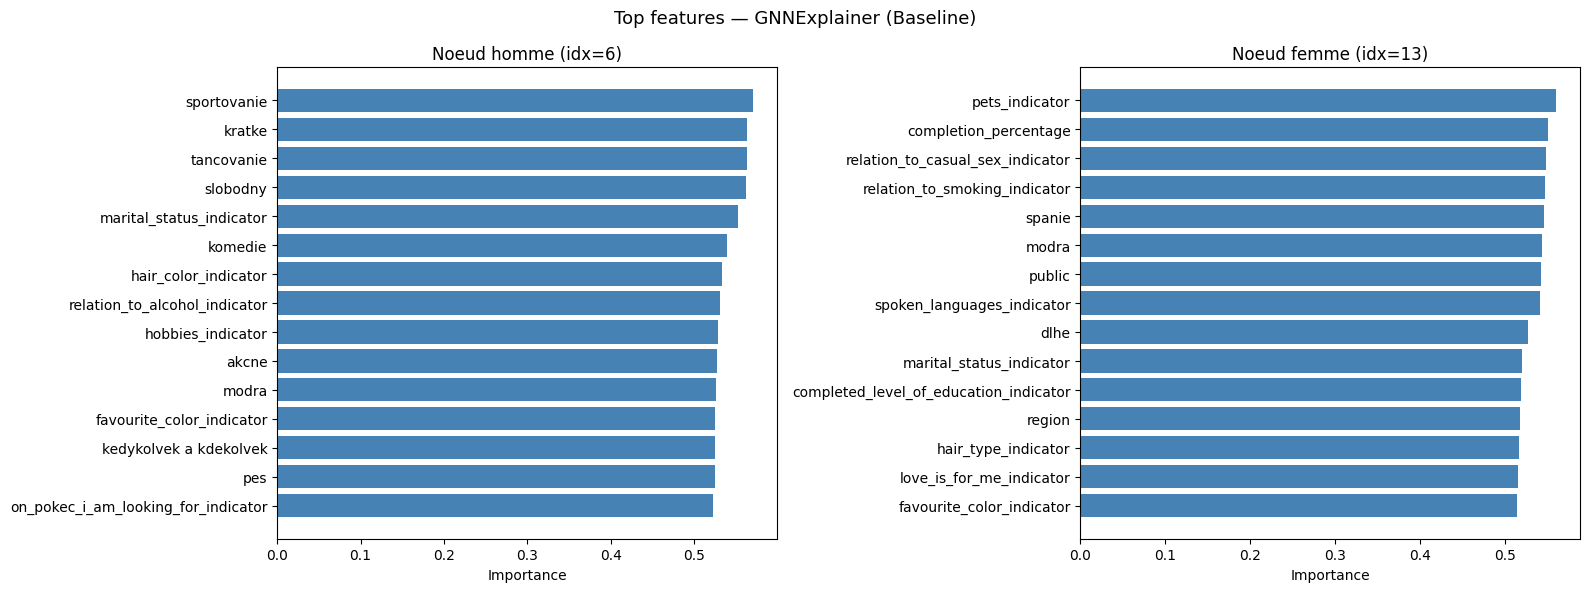

In [38]:
TOP_K = 15

def plot_top_features(exp, node_idx, title, ax, feat_names, k=TOP_K):
    imp     = exp.node_mask[node_idx].cpu().numpy()
    top_idx = np.argsort(imp)[-k:]
    ax.barh([feat_names[i] for i in top_idx], imp[top_idx], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Importance')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_top_features(exp_m, male_idx, f'Noeud homme (idx={male_idx})',   ax1, feature_cols)
plot_top_features(exp_f, female_idx, f'Noeud femme (idx={female_idx})', ax2, feature_cols)
plt.suptitle('Top features — GNNExplainer (Baseline)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Robustesse : bruit gaussien

In [34]:
def eval_noisy(model, data, sigma, n_runs=5, is_fair=False):
    results = []
    m, s, yt = data.test_mask.cpu().numpy(), data.sensitive_gender.cpu().numpy(), data.y.cpu().numpy()
    for _ in range(n_runs):
        x_n = data.x + sigma * torch.randn_like(data.x)
        model.eval()
        with torch.no_grad():
            out   = model.predict(x_n, data.edge_index) if is_fair else model(x_n, data.edge_index)
            probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds = out.argmax(dim=1).cpu().numpy()
        results.append({
            'Accuracy': accuracy_score(yt[m], preds[m]),
            'AUC-ROC':  roc_auc_score(yt[m], probs[m]),
            '|SPD|':    abs(spd(preds[m], s[m])),
            '|EOD|':    abs(eod(yt[m], preds[m], s[m])),
        })
    return pd.DataFrame(results).mean()

SIGMAS = [0.0, 0.1, 0.3, 0.5]

rob_base = pd.DataFrame([{'sigma': s, **eval_noisy(baseline,   data, s)}            for s in SIGMAS]).set_index('sigma')
rob_fair = pd.DataFrame([{'sigma': s, **eval_noisy(fair_model, data, s, is_fair=True)} for s in SIGMAS]).set_index('sigma')

print('=== Robustesse — Baseline ==='); print(rob_base.round(4))
print('\n=== Robustesse — Fair model ==='); print(rob_fair.round(4))

=== Robustesse — Baseline ===
       Accuracy  AUC-ROC   |SPD|   |EOD|
sigma                                   
0.0      0.4923   0.7759  0.0164  0.0112
0.1      0.4915   0.7759  0.0169  0.0123
0.3      0.4886   0.7729  0.0163  0.0120
0.5      0.4889   0.7684  0.0136  0.0113

=== Robustesse — Fair model ===
       Accuracy  AUC-ROC   |SPD|   |EOD|
sigma                                   
0.0      0.5151   0.7455  0.0151  0.0152
0.1      0.5154   0.7455  0.0144  0.0198
0.3      0.5144   0.7448  0.0130  0.0167
0.5      0.5136   0.7433  0.0149  0.0129


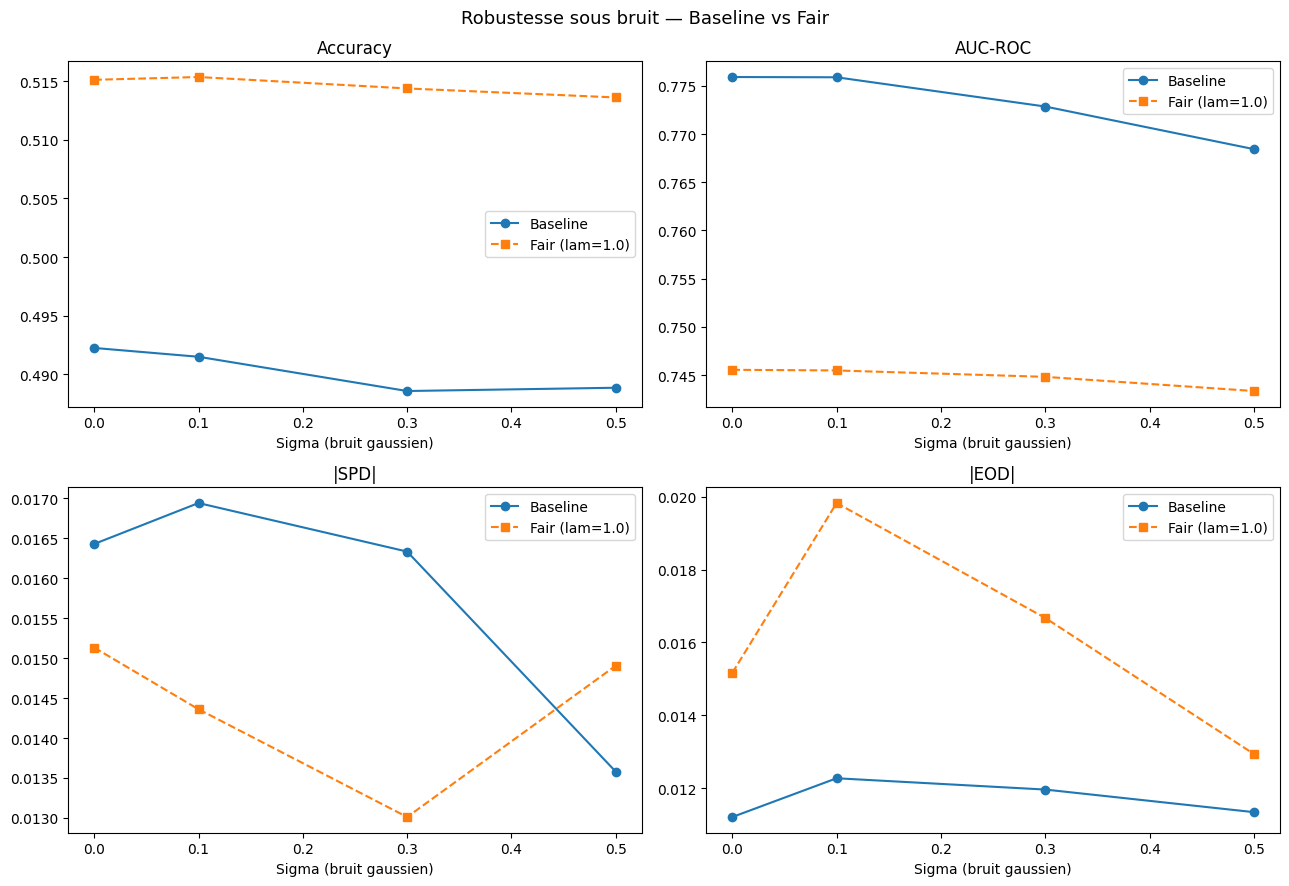

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, metric in enumerate(['Accuracy', 'AUC-ROC', '|SPD|', '|EOD|']):
    ax = axes[i // 2][i % 2]
    ax.plot(SIGMAS, rob_base[metric], marker='o', label='Baseline')
    ax.plot(SIGMAS, rob_fair[metric], marker='s', linestyle='--', label='Fair (lam=1.0)')
    ax.set_title(metric)
    ax.set_xlabel('Sigma (bruit gaussien)')
    ax.legend()
plt.suptitle('Robustesse sous bruit — Baseline vs Fair', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Resume final

In [36]:
print('=' * 55)
print('RESUME FINAL — Test set')
print('=' * 55)
for name, attr in [('Genre', data.sensitive_gender), ('Age', data.sensitive_age)]:
    rb = evaluate(baseline,   data, data.test_mask, attr)
    rf = evaluate(fair_model, data, data.test_mask, attr, is_fair=True)
    print(f'\nAttribut sensible : {name}')
    print(pd.DataFrame({'Baseline': rb, 'Fair': rf}).round(4))

RESUME FINAL — Test set

Attribut sensible : Genre
          Baseline    Fair
Accuracy    0.4923  0.5151
AUC-ROC     0.7759  0.7455
SPD         0.0164  0.0151
EOD        -0.0112 -0.0152

Attribut sensible : Age
          Baseline    Fair
Accuracy    0.4923  0.5151
AUC-ROC     0.7759  0.7455
SPD        -0.0603 -0.0664
EOD        -0.0464 -0.0575
